In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_raw = mnist.data.astype(float)   # shape: (70000, 784)
y = mnist.target.astype(int)        # shape: (70000,)

print("X shape:", X_raw.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))

X shape: (70000, 784)
y shape: (70000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [15]:
# (1) SVD analysis of digit images
# Each image is already a row vector of 784 pixels (28x28 flattened).
# We need each IMAGE as a COLUMN, so transpose: X shape -> (784, 70000)
X = X_raw.T
print("Data matrix X shape (pixels x images):", X.shape)

# Center the data (subtract mean face)
mean_digit = np.mean(X, axis=1, keepdims=True)
X_centered = X - mean_digit

# Perform SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
print("U shape:", U.shape)   # (784, r) - spatial modes
print("S shape:", S.shape)   # (r,)     - singular values
print("Vt shape:", Vt.shape) # (r, 70000) - temporal/image coefficients

Data matrix X shape (pixels x images): (784, 70000)
U shape: (784, 784)
S shape: (784,)
Vt shape: (784, 70000)


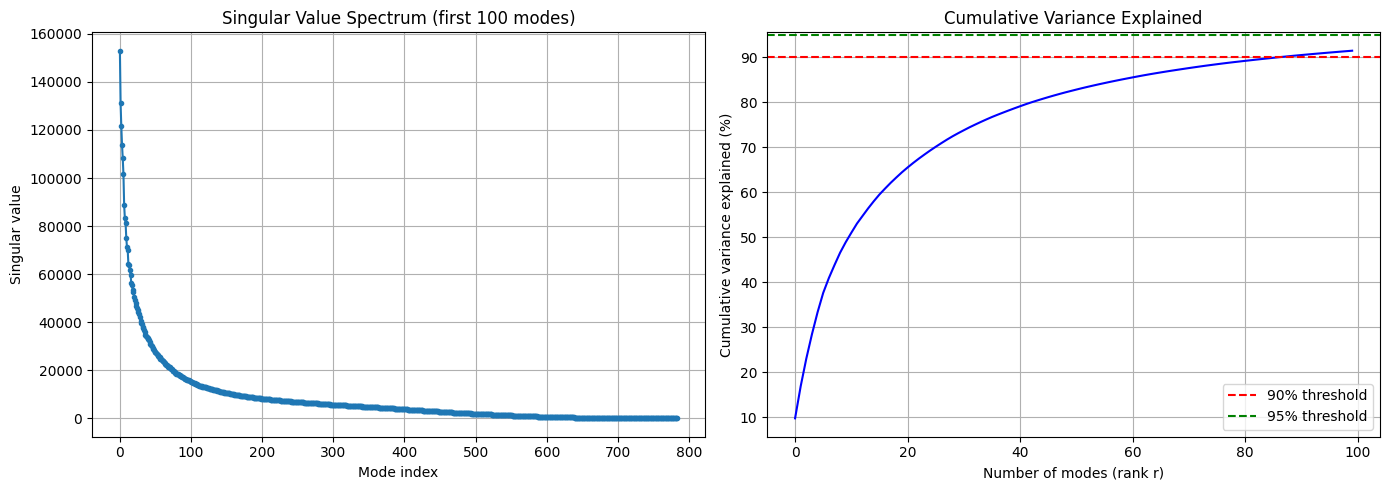

Modes needed for 80% variance: 43
Modes needed for 90% variance: 87
Modes needed for 95% variance: 154
Modes needed for 99% variance: 331


In [20]:
# (2) Singular value spectrum and rank of the digit space
variance_explained = (S ** 2) / np.sum(S ** 2) * 100
cumulative_variance = np.cumsum(variance_explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Singular value spectrum
axes[0].plot(S, 'o-', markersize=3)
axes[0].set_xlabel('Mode index')
axes[0].set_ylabel('Singular value')
axes[0].set_title('Singular Value Spectrum (first 100 modes)')
axes[0].grid(True)

# Cumulative variance explained
axes[1].plot(cumulative_variance[:100], 'b-')
axes[1].axhline(y=90, color='r', linestyle='--', label='90% threshold')
axes[1].axhline(y=95, color='g', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of modes (rank r)')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('singular_value_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# Find rank for common thresholds
for threshold in [80, 90, 95, 99]:
    rank = np.searchsorted(cumulative_variance, threshold) + 1
    print(f"Modes needed for {threshold}% variance: {rank}")

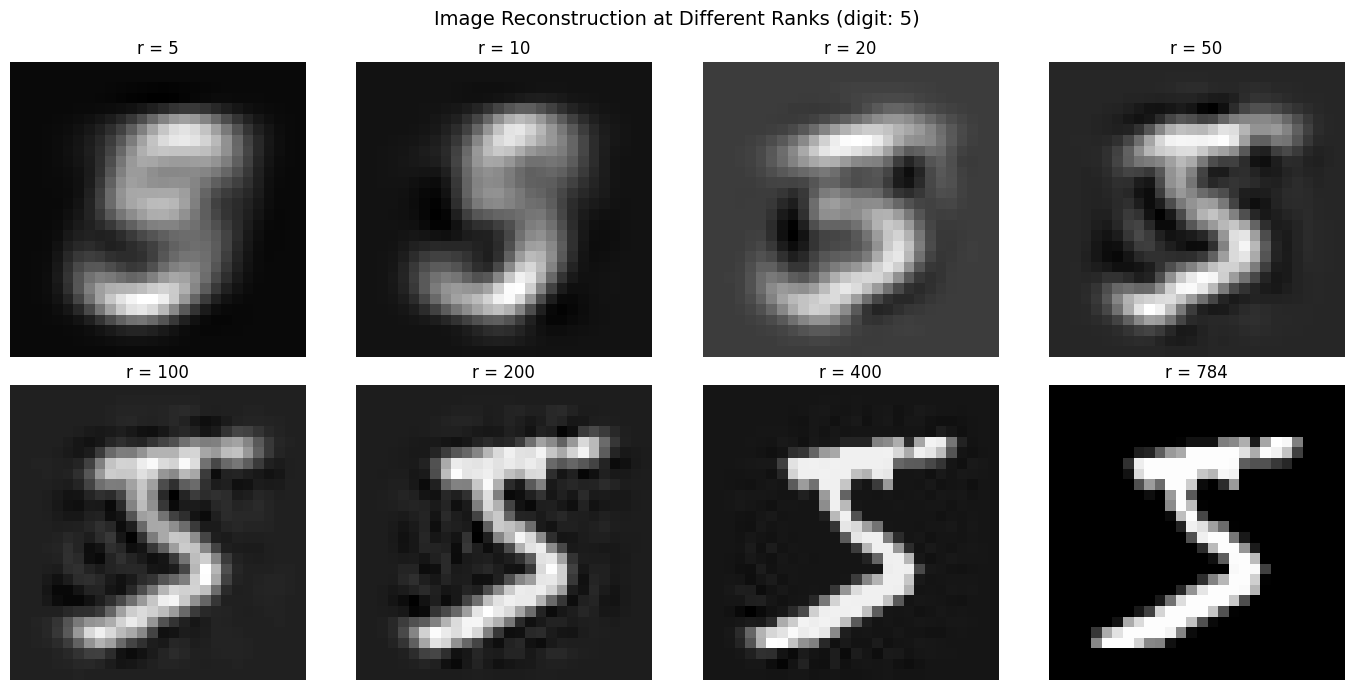

In [21]:
# (2 cont.) Visualize image reconstruction at different ranks
sample_idx = 0
sample_image = X_centered[:, sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
ranks = [5, 10, 20, 50, 100, 200, 400, 784]

for ax, r in zip(axes.flatten(), ranks):
    # Reconstruct using r modes
    recon = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, sample_idx]
    recon_image = (recon + mean_digit[:, 0]).reshape(28, 28)
    ax.imshow(recon_image, cmap='gray')
    ax.set_title(f'r = {r}')
    ax.axis('off')

plt.suptitle(f'Image Reconstruction at Different Ranks (digit: {y[sample_idx]})', fontsize=14)
plt.tight_layout()
plt.savefig('reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

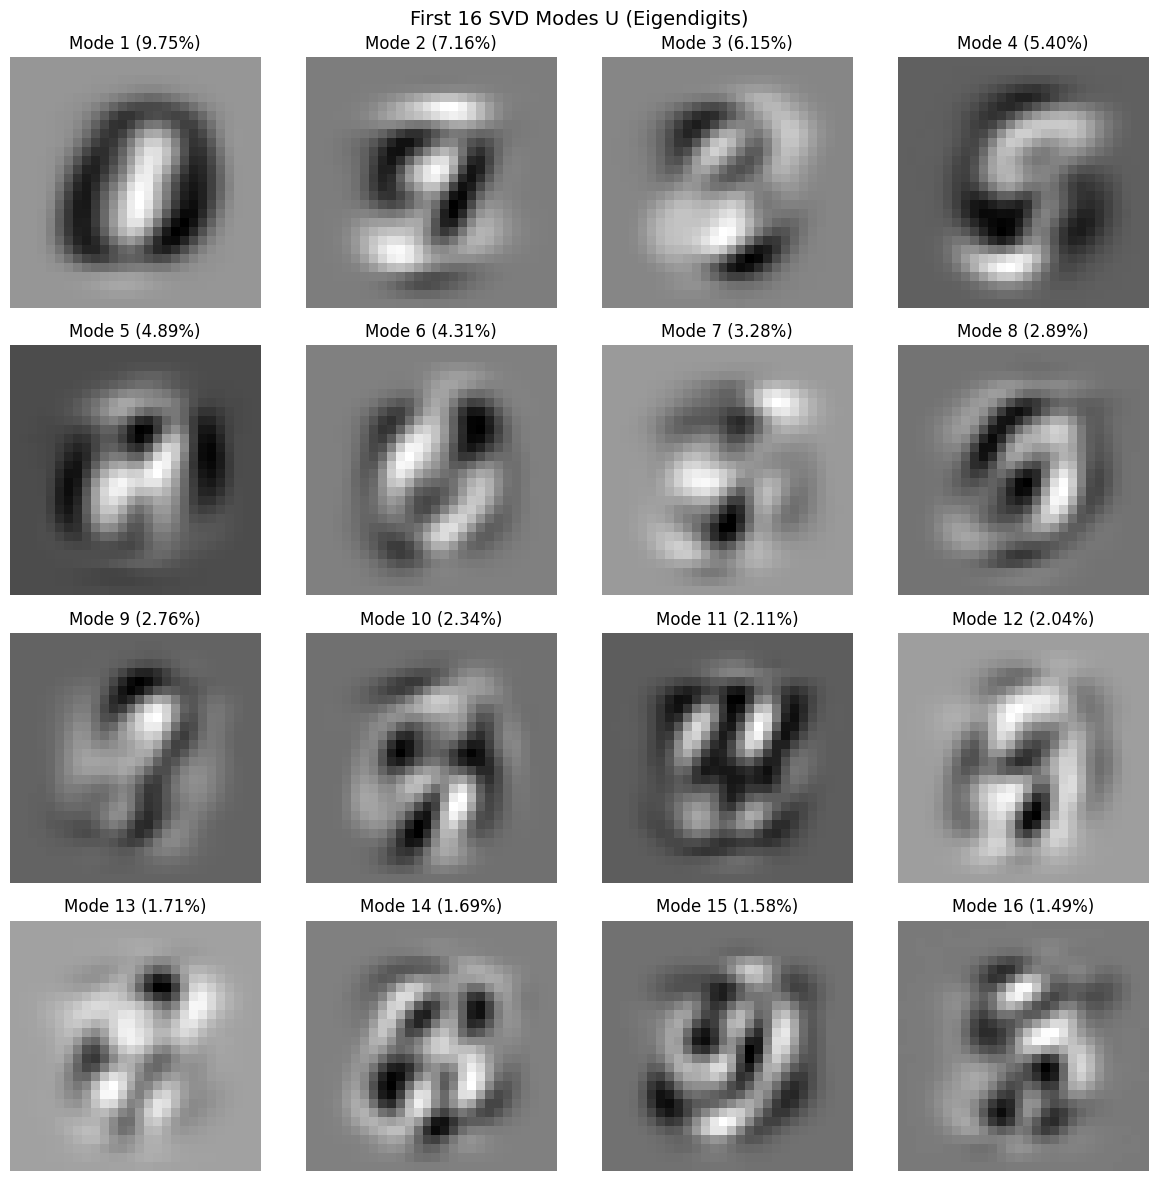

U (eigendigits): shape (784, 784) - basis images in pixel space
S (singular values): shape (784,) - energy/importance of each mode
Vt (image coefficients): shape (784, 70000) - each image's projection onto the modes


In [5]:
# (3) Interpretation of U, Sigma, V matrices
# U: left singular vectors - the 'eigendigits' (spatial modes, shape 784 x r)
#    Each column is a basis image in pixel space (like eigenfaces in HW3)
# S: singular values - the importance/energy of each mode
# V: right singular vectors - the projection of each image onto each mode
#    Each column of V corresponds to one image's representation in the mode space

# Plot the first 16 U modes (eigendigits)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
var_per_mode = (S[:16] ** 2) / np.sum(S ** 2) * 100

for i, ax in enumerate(axes.flatten()):
    ax.imshow(U[:, i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Mode {i+1} ({var_per_mode[i]:.2f}%)')
    ax.axis('off')

plt.suptitle('First 16 SVD Modes U (Eigendigits)', fontsize=14)
plt.tight_layout()
plt.savefig('eigendigits.png', dpi=150, bbox_inches='tight')
plt.show()

print("U (eigendigits): shape", U.shape, "- basis images in pixel space")
print("S (singular values): shape", S.shape, "- energy/importance of each mode")
print("Vt (image coefficients): shape", Vt.shape, "- each image's projection onto the modes")

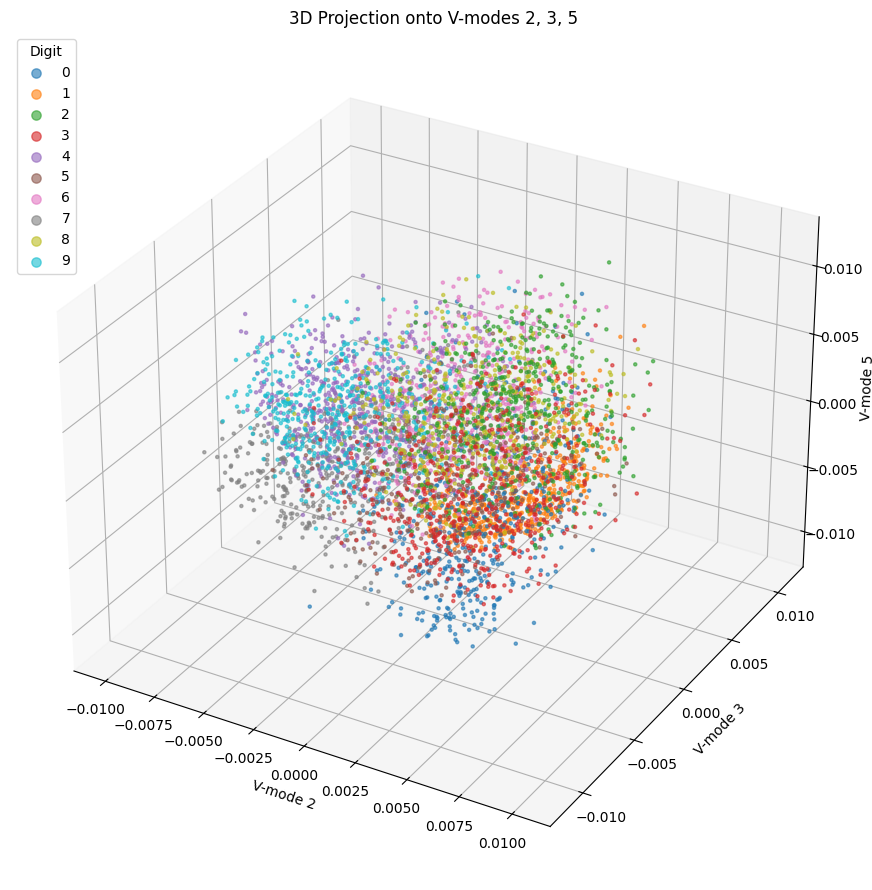

In [6]:
# (4) 3D projection onto three selected V-modes colored by digit label
# V has shape (r, 70000), so Vt[mode_idx, :] gives coordinates for all images along that mode.
# Use a subset for faster/cleaner plotting
subset = 5000
idx = np.random.choice(len(y), subset, replace=False)

# V-modes to project onto (0-indexed: columns 2, 3, 5 -> indices 1, 2, 4)
mode1, mode2, mode3 = 1, 2, 4  # columns 2, 3, 5 (1-indexed as in HW)

v1_coords = Vt[mode1, idx]
v2_coords = Vt[mode2, idx]
v3_coords = Vt[mode3, idx]
labels = y[idx]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for digit in range(10):
    mask = labels == digit
    ax.scatter(v1_coords[mask], v2_coords[mask], v3_coords[mask],
               c=[colors[digit]], label=str(digit), s=5, alpha=0.6)

ax.set_xlabel(f'V-mode {mode1+1}')
ax.set_ylabel(f'V-mode {mode2+1}')
ax.set_zlabel(f'V-mode {mode3+1}')
ax.set_title(f'3D Projection onto V-modes {mode1+1}, {mode2+1}, {mode3+1}')
ax.legend(title='Digit', markerscale=3, loc='upper left')
plt.tight_layout()
plt.savefig('3d_projection.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# EXTRA: Prepare PCA-projected features for classification
# Project all images onto the first r PCA modes
# Coordinates in PCA space: Z = Sigma @ Vt  (shape: r x 70000)
# Or equivalently: Z = U^T @ X_centered

r_pca = 100  # keep top 100 modes for classification
Z = (np.diag(S[:r_pca]) @ Vt[:r_pca, :]).T  # shape: (70000, r_pca)

# Train/test split (60k train / 10k test, standard MNIST split)
X_train, X_test, y_train, y_test = train_test_split(
    Z, y, test_size=10000, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:",  X_test.shape)

Train size: (60000, 100)
Test size: (10000, 100)


LDA on digits 3 vs 6
  Train accuracy: 0.9916
  Test  accuracy: 0.9945


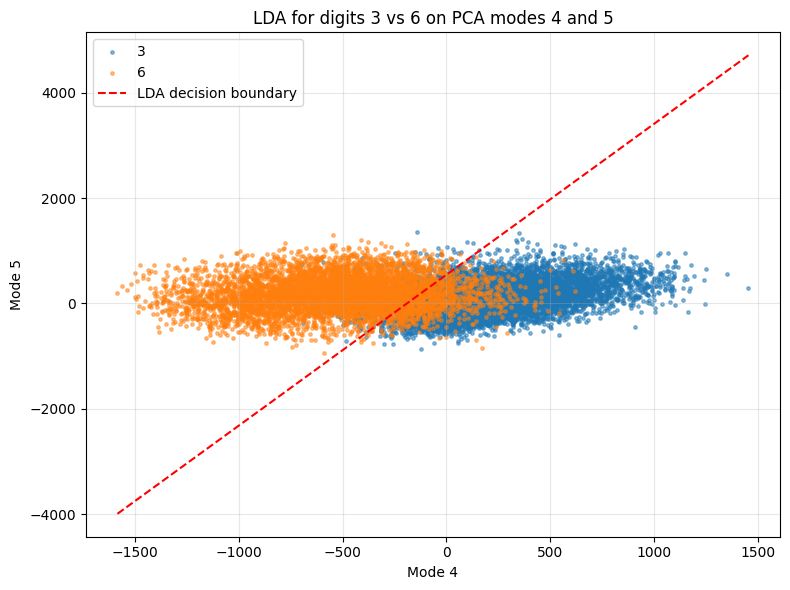

In [25]:
# EXTRA: LDA classifier for two digits (e.g., 1 and 7)
d1, d2 = 3, 6

mask_train = np.isin(y_train, [d1, d2])
mask_test  = np.isin(y_test,  [d1, d2])

lda_2 = LinearDiscriminantAnalysis()
lda_2.fit(X_train[mask_train], y_train[mask_train])

train_acc = accuracy_score(y_train[mask_train], lda_2.predict(X_train[mask_train]))
test_acc  = accuracy_score(y_test[mask_test],   lda_2.predict(X_test[mask_test]))

print(f"LDA on digits {d1} vs {d2}")
print(f"  Train accuracy: {train_acc:.4f}")
print(f"  Test  accuracy: {test_acc:.4f}")

# Visualize the linear boundary in the plane of PCA modes 4 and 5
mode_x, mode_y = 3, 4  # 0-indexed -> modes 4 and 5

X_vis = X_train[mask_train][:, [mode_x, mode_y]]
y_vis = y_train[mask_train]

lda_vis = LinearDiscriminantAnalysis()
lda_vis.fit(X_vis, y_vis)

plt.figure(figsize=(8, 6))
for digit in [d1, d2]:
    mask = y_vis == digit
    plt.scatter(X_vis[mask, 0], X_vis[mask, 1], s=6, alpha=0.5, label=str(digit))

x_vals = np.linspace(X_vis[:, 0].min(), X_vis[:, 0].max(), 200)
coef = lda_vis.coef_[0]
intercept = lda_vis.intercept_[0]

if abs(coef[1]) > 1e-12:
    y_vals = -(coef[0] * x_vals + intercept) / coef[1]
    plt.plot(x_vals, y_vals, 'r--', linewidth=1.5, label='LDA decision boundary')
else:
    x_boundary = -intercept / coef[0]
    plt.axvline(x_boundary, color='r', linestyle='--', linewidth=1.5, label='LDA decision boundary')

plt.xlabel(f'Mode {mode_x + 1}')
plt.ylabel(f'Mode {mode_y + 1}')
plt.title(f'LDA for digits {d1} vs {d2} on PCA modes {mode_x + 1} and {mode_y + 1}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# EXTRA: LDA classifier for three digits (e.g., 1, 4, 7)
d1, d2, d3 = 1, 4, 7

mask_train_3 = np.isin(y_train, [d1, d2, d3])
mask_test_3  = np.isin(y_test,  [d1, d2, d3])

lda_3 = LinearDiscriminantAnalysis()
lda_3.fit(X_train[mask_train_3], y_train[mask_train_3])

train_acc_3 = accuracy_score(y_train[mask_train_3], lda_3.predict(X_train[mask_train_3]))
test_acc_3  = accuracy_score(y_test[mask_test_3],   lda_3.predict(X_test[mask_test_3]))

print(f"LDA on digits {d1}, {d2}, {d3}")
print(f"  Train accuracy: {train_acc_3:.4f}")
print(f"  Test  accuracy: {test_acc_3:.4f}")

LDA on digits 1, 4, 7
  Train accuracy: 0.9821
  Test  accuracy: 0.9838


In [10]:
# EXTRA: Find hardest and easiest digit pairs to separate with LDA
# Test all 45 pairs

from itertools import combinations

pair_results = []

for d1, d2 in combinations(range(10), 2):
    mask_train_p = np.isin(y_train, [d1, d2])
    mask_test_p  = np.isin(y_test,  [d1, d2])
    
    lda_p = LinearDiscriminantAnalysis()
    lda_p.fit(X_train[mask_train_p], y_train[mask_train_p])
    acc = accuracy_score(y_test[mask_test_p], lda_p.predict(X_test[mask_test_p]))
    pair_results.append((d1, d2, acc))

pair_results.sort(key=lambda x: x[2])

print("5 Hardest pairs (lowest LDA test accuracy):")
for d1, d2, acc in pair_results[:5]:
    print(f"  Digits {d1} vs {d2}: {acc:.4f}")

print("\n5 Easiest pairs (highest LDA test accuracy):")
for d1, d2, acc in pair_results[-5:][::-1]:
    print(f"  Digits {d1} vs {d2}: {acc:.4f}")

hardest_pair = pair_results[0][:2]
easiest_pair = pair_results[-1][:2]
print(f"\nHardest pair: {hardest_pair}")
print(f"Easiest pair: {easiest_pair}")

5 Hardest pairs (lowest LDA test accuracy):
  Digits 4 vs 9: 0.9482
  Digits 5 vs 8: 0.9547
  Digits 3 vs 5: 0.9558
  Digits 3 vs 8: 0.9604
  Digits 7 vs 9: 0.9656

5 Easiest pairs (highest LDA test accuracy):
  Digits 1 vs 6: 0.9976
  Digits 6 vs 7: 0.9975
  Digits 6 vs 9: 0.9975
  Digits 1 vs 4: 0.9971
  Digits 0 vs 1: 0.9957

Hardest pair: (4, 9)
Easiest pair: (1, 6)


In [11]:
# EXTRA: SVM and Decision Tree on all 10 digits
# Use a subset for speed; SVM on full 60k can be slow
subset_size = 10000
idx_sub = np.random.choice(len(X_train), subset_size, replace=False)
X_tr_sub = X_train[idx_sub]
y_tr_sub = y_train[idx_sub]

# SVM
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_tr_sub, y_tr_sub)
svm_train_acc = accuracy_score(y_tr_sub, svm.predict(X_tr_sub))
svm_test_acc  = accuracy_score(y_test, svm.predict(X_test))

# Decision Tree
dt = DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_tr_sub, y_tr_sub)
dt_train_acc = accuracy_score(y_tr_sub, dt.predict(X_tr_sub))
dt_test_acc  = accuracy_score(y_test, dt.predict(X_test))

# LDA on all 10 digits
lda_all = LinearDiscriminantAnalysis()
lda_all.fit(X_tr_sub, y_tr_sub)
lda_train_acc = accuracy_score(y_tr_sub, lda_all.predict(X_tr_sub))
lda_test_acc  = accuracy_score(y_test, lda_all.predict(X_test))

print("All 10 digits classification:")
print(f"  LDA:  train={lda_train_acc:.4f}, test={lda_test_acc:.4f}")
print(f"  SVM:  train={svm_train_acc:.4f}, test={svm_test_acc:.4f}")
print(f"  DTree: train={dt_train_acc:.4f}, test={dt_test_acc:.4f}")

All 10 digits classification:
  LDA:  train=0.8775, test=0.8709
  SVM:  train=1.0000, test=0.9724
  DTree: train=0.9969, test=0.7755


In [12]:
# EXTRA: Compare LDA, SVM, Decision Tree on hardest and easiest pairs

def compare_classifiers(pair, X_train, y_train, X_test, y_test):
    d1, d2 = pair
    mask_tr = np.isin(y_train, [d1, d2])
    mask_te = np.isin(y_test,  [d1, d2])
    Xtr, ytr = X_train[mask_tr], y_train[mask_tr]
    Xte, yte = X_test[mask_te],  y_test[mask_te]

    results = {}
    for name, clf in [("LDA", LinearDiscriminantAnalysis()),
                      ("SVM", SVC(kernel='rbf', C=10, gamma='scale', random_state=42)),
                      ("DTree", DecisionTreeClassifier(max_depth=20, random_state=42))]:
        clf.fit(Xtr, ytr)
        results[name] = {
            'train': accuracy_score(ytr, clf.predict(Xtr)),
            'test':  accuracy_score(yte, clf.predict(Xte))
        }
    return results

print(f"Hardest pair: digits {hardest_pair[0]} vs {hardest_pair[1]}")
hard_results = compare_classifiers(hardest_pair, X_train, y_train, X_test, y_test)
for clf_name, accs in hard_results.items():
    print(f"  {clf_name}: train={accs['train']:.4f}, test={accs['test']:.4f}")

print(f"\nEasiest pair: digits {easiest_pair[0]} vs {easiest_pair[1]}")
easy_results = compare_classifiers(easiest_pair, X_train, y_train, X_test, y_test)
for clf_name, accs in easy_results.items():
    print(f"  {clf_name}: train={accs['train']:.4f}, test={accs['test']:.4f}")

Hardest pair: digits 4 vs 9
  LDA: train=0.9588, test=0.9482
  SVM: train=0.9999, test=0.9924
  DTree: train=0.9947, test=0.8928

Easiest pair: digits 1 vs 6
  LDA: train=0.9960, test=0.9976
  SVM: train=1.0000, test=0.9991
  DTree: train=1.0000, test=0.9881


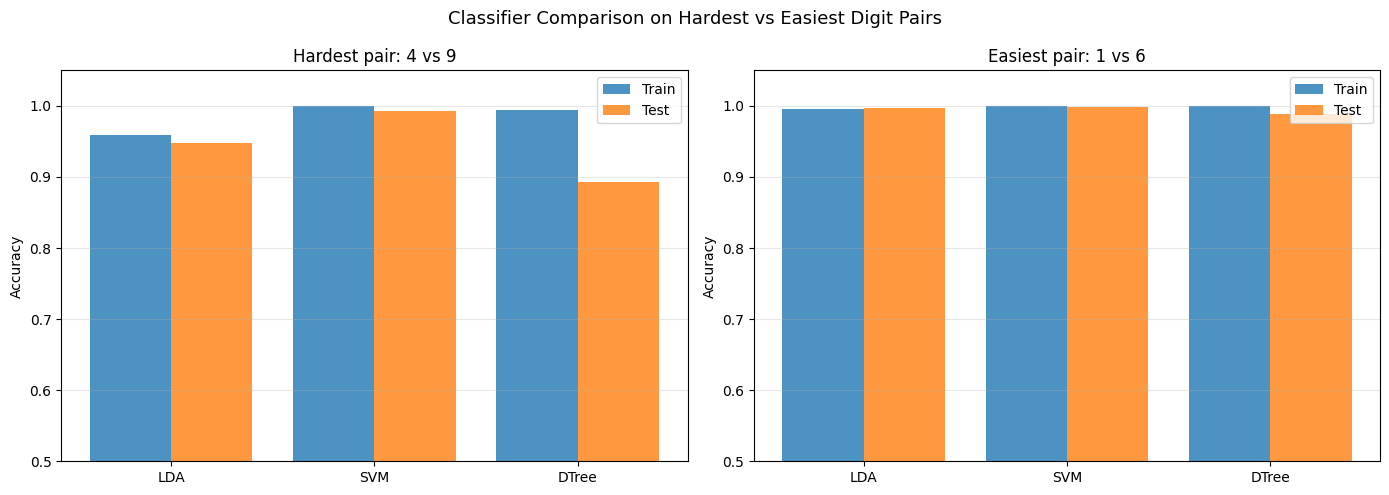

In [13]:
# Summary bar chart comparing classifiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classifiers = ['LDA', 'SVM', 'DTree']

for ax, results, title in [
    (axes[0], hard_results, f'Hardest pair: {hardest_pair[0]} vs {hardest_pair[1]}'),
    (axes[1], easy_results, f'Easiest pair: {easiest_pair[0]} vs {easiest_pair[1]}')
]:
    x = np.arange(len(classifiers))
    train_accs = [results[c]['train'] for c in classifiers]
    test_accs  = [results[c]['test']  for c in classifiers]
    ax.bar(x - 0.2, train_accs, 0.4, label='Train', alpha=0.8)
    ax.bar(x + 0.2, test_accs,  0.4, label='Test',  alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(classifiers)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Classifier Comparison on Hardest vs Easiest Digit Pairs', fontsize=13)
plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()